# Using Multiple Regression to Model Exchange Rates

In this notebook, we use Federal Reserve exchange rate data to build a model that predicts the USD/GBP exchange rate based on the exchange rate between USD and other currencies.

Let's start by loading the data from the file 'USD_Monthly_Exch_Rates_2021-25.csv', which gives monthly exchange rate information for the period 2021-25. We'll then do a bit of data processing that standardizes the units.

In [1]:
# import libraries and load data from CSV file
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime as dt
import seaborn

file = 'USD_Monthly_Exch_Rates_2021-25.csv'
currency = pd.read_csv(file)

# Some data processing:
# Rename columns, convert all columns into what $1 USD equals in other currency
# Convert string dates to datetime objects

currency.columns = ['Month', 'Eur', 'GBP', 'SF', 'AUD', 'NZD']
currency['Eur'] = 1/currency['Eur']
currency['GBP'] = 1/currency['GBP']
currency['AUD'] = 1/currency['AUD']
currency['NZD'] = 1/currency['NZD']
currency['Month'] = pd.to_datetime(currency['Month'], format="%m/%d/%Y")
currency.head()

,Month,Eur,GBP,SF,AUD,NZD
0,2021-01-01,0.821153,0.733084,0.8865,1.294331,1.388889
1,2021-02-01,0.826856,0.721137,0.8979,1.289823,1.380262
2,2021-03-01,0.840195,0.721345,0.9298,1.297017,1.401345
3,2021-04-01,0.835771,0.722282,0.9218,1.298533,1.403115
4,2021-05-01,0.823316,0.710026,0.9027,1.288162,1.384083


## Task 1: Plot Time Series Graphs

The `pandas` dataframe called `currency` contains the value of \\$1 USD in Euros, British Pounds, Swiss Francs, Australian Dollars and New Zealand Dollars. Before we build the regression model, let's plot graphs of \\$1 USD in each currency over the 5 year period.

The code below plots the value of one USD in GBP and Euros. Add in the plots for SF, AUD and NZD, plotting them all on the same axes with an appropriate title and legend.

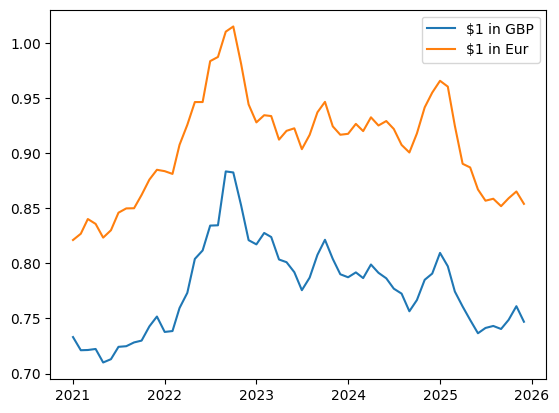

In [2]:
# Before we create the model, let's look at the graphs of $1 USD in each currency over time to see if there are any clear patterns.

plt.plot(currency['Month'], currency['GBP'], label='$1 in GBP')
plt.plot(currency['Month'], currency['Eur'], label = '$1 in Eur')

# ADD IN PLOTS here for the other currencies here

plt.legend()
plt.show()

## Task 2: Pairwise Correlation

We can calculate pairwise correlations for all the currencies in the table. This will help us to see what currencies have the strongest linear assocation. The `seaborn` library can also help to visualize this.

In [ ]:
# Calculate the matrix of pairwise correlations for the currencies
correlation_matrix = currency.iloc[:, 1:6].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(6, 4))
seaborn.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

## Task 3: Analyze Patterns

What trends do you see? Are there some currencies that seem to move together more than others? Write a couple of sentences explaining what you see from the graph and the correlation matrix.

**Write your answer here**

## Task 4: Build Regression Model

Let's build a regression model that predicts the value of one USD in GBP based on the value of one USD in some of the other other currencies. You can choose how many currencies you want to include in your model as independent variables.

Modify the code below to set the independent variables `X` and the dependent variable `y`. The dependent variable will be the GBP column in the table.

In [ ]:
# Build model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#  MODIFY THE CODE HERE to include more than one currency for the indepedent variables and to set the dependent variable to GBP
X = currency[['SF']] # One or more independent variables
y = currency['Eur']  # Single dependent variable - change this to GBP

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Make predictions
GBP_predict = model.predict(X)
currency['GBP_predict'] = GBP_predict

coeffs = model.coef_
intercept = model.intercept_
r_sq = model.score(X, y)

print(f"Coefficients: {coeffs}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_sq:.4f}")

## Task 5: Interpret Model Parameters

What do the coefficients and r-squared values tell you? Overall, is the model a good fit? Which currencies appeared to have a stronger effect on the value of one USD in GBP than others? Are there any currencies you might want to drop?

**Write your answer here**

## Task 6: Plot Time Series for Actual Rate Versus Model

Now plot a graph of currency value against time for GBP and the model prediction. The Actual GBP rate has been done for you - you just need to add the model values to the plot.

In [ ]:
# Plot time series for actual vs model 
plt.plot(currency['Month'], currency['GBP'], label="Actual")

# ADD CODE HERE - Plot the model values on the same axes

plt.xlabel("Time")
plt.ylabel("Value of $1 USD in GBP")
plt.title("Values of $1 in GBP over time - actual vs model")
plt.legend()
plt.show()

## Task 7: Interpret Time Series Graph

Based on the time series graph, how good is the model? Does it do a good job of predicting the USD/GBP exchange rate? Comment on how good you think the model is and what its shortcomings might be.

**Write your answer here**

## Task 8: Examine Residuals

Create a column in the dataframe called `Residual`. This will be the difference between the `GBP` and 'GBP_predict` columns.

Then run the code that follows to create a plot of the residuals.

In [ ]:
# Type your code here


## Task 9: Create a Residual Plot

You need to have created the right columns for this code to work.

In [ ]:
# Plot residuals
x = currency['Month']
residuals = currency['Residual']

plt.scatter(x, residuals)
plt.plot([x.min(), x.max()], [0,0])
for i in range(len(residuals)):
    plt.plot([x[i], x[i]], [0, residuals[i]], ':b')
plt.title("Residual Plot for Model")
plt.xlabel("Time")
plt.ylabel("Residual: y - y_hat")
plt.show()

## Task 10: Comment on Residual Plot

What is the residual plot telling you? Is the linear model a good fit? Is there any non-linear behavior detectable from the plot?

**Write your answer here**

## Task 11: Use Model for a Different Time Period

Use the model you have created to predict the value of one USD in GBP for a different time period. For example, you could use the model coefficients and today's exchange rates for Eur/SF/NZD/AUD to predict the current USD-GBP exchange rate for today. Or you could download a whole dataset from [St Louis Fred](https://fred.stlouisfed.org/categories/15).

Is the model any good at predicting exchange rates outside the original time window?

In [ ]:
# Type your code here
